# EEG-Based MDD Classification: Asymmetry + DFA → SVM Pipeline
## Dual-Dataset · Linear + Nonlinear Features · Three Channel Configurations

**Methodology pipeline:**
```
Dataset 1 (Malaysia, 19-ch, 256 Hz)  +  Dataset 2 (India, 128-ch, 512 Hz)
         ↓                                        ↓
   Resample to 256 Hz            Resample to 256 Hz + channel intersect
         ↓__________________________↓
              Merged Preprocessing Stream
              → Bandpass filter [0.5 – 32 Hz]
              → Common Average Reference (CAR)
              → ICA eyeblink removal
              → 2-second epoch segmentation
              → Amplitude-based noise rejection
              → 8,572 clean epochs
                  ↓
         Feature Extraction (per epoch)
         ├─ Linear  : Paired asymmetry (delta, alpha, beta band power)
         └─ Nonlinear: DFA scaling exponent per channel
                  ↓
         Min-Max Normalization
                  ↓
         Three Channel Models evaluated:
         ├─ Model 1: All available channels
         ├─ Model 2: 6-channel  (F7, F8, T7, T8, P7, P8)
         └─ Model 3: 4-channel  ★ T7, T8, P7, P8  [91.74% Acc]
                  ↓
         SVM (Gaussian/RBF kernel)
         10-fold CV × 100 repetitions | 70% train / 30% test
                  ↓
         Accuracy · Sensitivity · Specificity
```


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 1 — Mount Google Drive (Google Colab only)
# ═══════════════════════════════════════════════════════════════════════════

import os

EEG_DIR = '/Users/tanvirm/Documents/EEG/'

if not os.path.isdir(EEG_DIR):
    raise FileNotFoundError(f'Folder not found: {EEG_DIR}')

all_files = sorted([f for f in os.listdir(EEG_DIR) if f.endswith('.edf')])
mdd_files = [f for f in all_files if os.path.splitext(f)[0].startswith('MDD')]
hc_files  = [f for f in all_files if os.path.splitext(f)[0].startswith('H')]

print(f'EEG folder   : {EEG_DIR}')
print(f'Total .edf   : {len(all_files)}')
print(f'MDD files    : {len(mdd_files)}  (prefix=MDD)')
print(f'HC  files    : {len(hc_files)}   (prefix=H)')
print(f'Sample names : {all_files[:4]}')


EEG folder   : /Users/tanvirm/Documents/EEG/
Total .edf   : 181
MDD files    : 95  (prefix=MDD)
HC  files    : 84   (prefix=H)
Sample names : ['6921143_H S15 EO.edf', '6921959_H S15 EO.edf', 'H S1 EO.edf', 'H S1 TASK.edf']


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 2 — Install dependencies and imports
# ═══════════════════════════════════════════════════════════════════════════
# !pip install mne numpy scipy scikit-learn matplotlib seaborn pandas tqdm

import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import mne
from scipy.signal import welch
from scipy.stats  import pearsonr

from sklearn.svm              import SVC
from sklearn.preprocessing    import MinMaxScaler
from sklearn.model_selection  import StratifiedKFold
from sklearn.metrics          import (accuracy_score, confusion_matrix,
                                      f1_score, roc_auc_score)

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

SEED = 42
np.random.seed(SEED)

print(f'MNE       : {mne.__version__}')
print(f'NumPy     : {np.__version__}')
print('All imports OK.')


MNE       : 1.11.0
NumPy     : 2.3.5
All imports OK.


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 3 — Global Configuration
# ═══════════════════════════════════════════════════════════════════════════
EEG_DIR = '/Users/tanvirm/Documents/EEG/'

CFG = {
    # ── Dataset ────────────────────────────────────────────────────────
    'eeg_dir'      : '/Users/tanvirm/Documents/EEG/',
    'proc_dir'     : '/Users/tanvirm/Documents/EEG/processed/',
    'results_dir'  : '/Users/tanvirm/Documents/EEG/results/',
    'mdd_prefix'   : 'MDD',
    'hc_prefix'    : 'H',

    # ── EEG signal ─────────────────────────────────────────────────────
    'sfreq_target' : 256,
    'l_freq'       : 0.5,
    'h_freq'       : 32.0,
    'notch_freq'   : 50.0,
    'n_ica_components': 15,
    'ica_eog_ch'   : None,

    # ── Epoching ───────────────────────────────────────────────────────
    'epoch_sec'    : 2.0,
    'amp_thresh'   : 100e-6,

    # ── Frequency bands for asymmetry features ─────────────────────────
    'bands' : {
        'delta' : (0.5,  4.0),
        'alpha' : (8.0,  13.0),
        'beta'  : (13.0, 30.0),
    },

    # ── DFA parameters ─────────────────────────────────────────────────
    'dfa_scales' : np.logspace(np.log10(10), np.log10(200), 8).astype(int),

    # ── 19 standard channels (your dataset naming) ──────────────────────
    'channels_19' : ['EEG Fp1-LE', 'EEG F3-LE',  'EEG C3-LE',  'EEG P3-LE',
                     'EEG O1-LE',  'EEG F7-LE',  'EEG T3-LE',  'EEG T5-LE',
                     'EEG Fz-LE',  'EEG Fp2-LE', 'EEG F4-LE',  'EEG C4-LE',
                     'EEG P4-LE',  'EEG O2-LE',  'EEG F8-LE',  'EEG T4-LE',
                     'EEG T6-LE',  'EEG Cz-LE',  'EEG Pz-LE'],

    # ── Model 2: 6-channel (frontal + temporal + parieto-temporal) ──────
    # F7/F8 = frontal lateral | T3/T4 = temporal | T5/T6 = parieto-temporal
    'channels_6'  : ['EEG F7-LE', 'EEG F8-LE',
                     'EEG T3-LE', 'EEG T4-LE',
                     'EEG T5-LE', 'EEG T6-LE'],

    # ── Model 3 ★: 4-channel frontal (portable, user-specified) ─────────
    'channels_4'  : ['EEG Fp1-LE', 'EEG Fp2-LE',
                     'EEG F3-LE',  'EEG F4-LE'],

    # ── Asymmetry pairs: (left_ch, right_ch) ───────────────────────────
    # Uses hemisphere-symmetric pairs from the 19-channel set
    'asym_pairs' : [
        ('EEG Fp1-LE', 'EEG Fp2-LE'),   # frontopolar
        ('EEG F3-LE',  'EEG F4-LE'),    # frontal
        ('EEG F7-LE',  'EEG F8-LE'),    # frontal lateral
        ('EEG T3-LE',  'EEG T4-LE'),    # temporal
        ('EEG T5-LE',  'EEG T6-LE'),    # parieto-temporal
        ('EEG C3-LE',  'EEG C4-LE'),    # central
        ('EEG P3-LE',  'EEG P4-LE'),    # parietal
        ('EEG O1-LE',  'EEG O2-LE'),    # occipital
    ],

    # ── SVM ────────────────────────────────────────────────────────────
    'n_repeats'   : 100,
    'k_folds'     : 10,
    'train_ratio' : 0.70,
    'svm_C'       : 1.0,
    'svm_gamma'   : 'scale',
}

os.makedirs(CFG['proc_dir'],    exist_ok=True)
os.makedirs(CFG['results_dir'], exist_ok=True)

print('Configuration loaded.')
print(f'  EEG folder     : {CFG["eeg_dir"]}')
print(f'  Channels (19)  : {len(CFG["channels_19"])}')
print(f'  Channels (6)   : {len(CFG["channels_6"])}  — {CFG["channels_6"]}')
print(f'  Channels (4) ★ : {len(CFG["channels_4"])}  — {CFG["channels_4"]}')
print(f'  Asymmetry pairs: {len(CFG["asym_pairs"])} pairs × {len(CFG["bands"])} bands = '
      f'{len(CFG["asym_pairs"]) * len(CFG["bands"])} asymmetry features')
print(f'  SVM repeats    : {CFG["n_repeats"]} × {CFG["k_folds"]}-fold CV')


Configuration loaded.
  EEG folder     : /Users/tanvirm/Documents/EEG/
  Channels (19)  : 19
  Channels (6)   : 6  — ['EEG F7-LE', 'EEG F8-LE', 'EEG T3-LE', 'EEG T4-LE', 'EEG T5-LE', 'EEG T6-LE']
  Channels (4) ★ : 4  — ['EEG Fp1-LE', 'EEG Fp2-LE', 'EEG F3-LE', 'EEG F4-LE']
  Asymmetry pairs: 8 pairs × 3 bands = 24 asymmetry features
  SVM repeats    : 100 × 10-fold CV


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 4 — Dataset Audit
#  Inspect the single EEG folder, verify naming and channel layout
# ═══════════════════════════════════════════════════════════════════════════

eeg_dir = CFG['eeg_dir']
all_edf  = sorted([f for f in os.listdir(eeg_dir) if f.endswith('.edf')])
mdd_edf  = [f for f in all_edf if os.path.splitext(f)[0].startswith(CFG['mdd_prefix'])]
hc_edf   = [f for f in all_edf if os.path.splitext(f)[0].startswith(CFG['hc_prefix'])]
unmatched= [f for f in all_edf if f not in mdd_edf and f not in hc_edf]

print('═' * 60)
print('  DATASET AUDIT')
print('═' * 60)
print(f'  Folder    : {eeg_dir}')
print(f'  Total     : {len(all_edf)} .edf files')
print(f'  MDD files : {len(mdd_edf)}')
print(f'  HC  files : {len(hc_edf)}')
if unmatched:
    print(f'  UNMATCHED : {unmatched}  ← check prefix in CFG')

# ── Peek at one MDD and one HC file ────────────────────────────────
for sample_file, group in [(mdd_edf[0] if mdd_edf else None, 'MDD'),
                            (hc_edf[0]  if hc_edf  else None, 'HC')]:
    if sample_file is None:
        continue
    raw = mne.io.read_raw_edf(os.path.join(eeg_dir, sample_file),
                               preload=False, verbose=False)
    print(f'\n  Sample [{group}]: {sample_file}')
    print(f'    sfreq      : {raw.info["sfreq"]} Hz')
    print(f'    n_channels : {len(raw.ch_names)}')
    print(f'    duration   : {raw.times[-1]:.1f} s')
    print(f'    ch_names   : {raw.ch_names[:6]} ...')

    # Verify our 19 channel names exist in the file
    missing_ch = [ch for ch in CFG['channels_19'] if ch not in raw.ch_names]
    ok_ch      = [ch for ch in CFG['channels_19'] if ch in raw.ch_names]
    print(f'    channels_19 found   : {len(ok_ch)}/19')
    if missing_ch:
        print(f'    MISSING channels    : {missing_ch}')
        print(f'    ► Update CFG channels_19/6/4 to match actual names above')

print('\n' + '═' * 60)


════════════════════════════════════════════════════════════
  DATASET AUDIT
════════════════════════════════════════════════════════════
  Folder    : /Users/tanvirm/Documents/EEG/
  Total     : 181 .edf files
  MDD files : 95
  HC  files : 84
  UNMATCHED : ['6921143_H S15 EO.edf', '6921959_H S15 EO.edf']  ← check prefix in CFG

  Sample [MDD]: MDD S1  EO.edf
    sfreq      : 256.0 Hz
    n_channels : 20
    duration   : 301.0 s
    ch_names   : ['EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE', 'EEG F7-LE'] ...
    channels_19 found   : 19/19

  Sample [HC]: H S1 EO.edf
    sfreq      : 256.0 Hz
    n_channels : 22
    duration   : 351.0 s
    ch_names   : ['EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE', 'EEG F7-LE'] ...
    channels_19 found   : 19/19

════════════════════════════════════════════════════════════


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 5 — Preprocessing Functions
#  Pipeline: Load → Resample → Bandpass → Notch → CAR → ICA → Segment
# ═══════════════════════════════════════════════════════════════════════════

def load_and_resample(filepath, target_sfreq, channel_set=None):
    """
    Load EDF, optionally pick channels, resample to target_sfreq.
    Returns MNE Raw object.
    """
    raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)

    # Pick channels if specified
    if channel_set is not None:
        available = [ch for ch in channel_set if ch in raw.ch_names]
        if len(available) == 0:
            raise ValueError(f'None of the requested channels found in {filepath}')
        if len(available) < len(channel_set):
            missing = set(channel_set) - set(available)
            print(f'  WARNING missing: {missing}')
        raw.pick_channels(available)

    # Resample if needed
    if raw.info['sfreq'] != target_sfreq:
        raw.resample(target_sfreq, npad='auto', verbose=False)

    return raw


def apply_signal_conditioning(raw, cfg):
    """
    Step 1: Bandpass filter [0.5–32 Hz] — zero-phase FIR Hamming
    Step 2: Notch filter [50, 100, 150 Hz]
    Step 3: Common Average Reference (CAR)
    Returns conditioned Raw.
    """
    # Bandpass
    raw.filter(l_freq=cfg['l_freq'], h_freq=cfg['h_freq'],
               method='fir', fir_window='hamming', verbose=False)

    # Notch
    notch_freqs = [cfg['notch_freq'] * k
                   for k in range(1, 4)
                   if cfg['notch_freq'] * k < cfg['sfreq_target'] / 2]
    raw.notch_filter(freqs=notch_freqs, verbose=False)

    # CAR — Common Average Reference
    raw.set_eeg_reference('average', projection=False, verbose=False)

    return raw


def apply_ica_eyeblink_removal(raw, cfg):
    """
    Fit ICA on the cleaned signal and auto-detect eye-blink components.
    Uses correlation with frontal channels (Fp1/Fp2) as proxy if no EOG channel.
    Returns ICA-cleaned Raw.

    NOTE: ICA requires ≥ 3 × n_components seconds of data.
    If recording is too short, ICA is skipped with a warning.
    """
    min_duration_needed = 3 * cfg['n_ica_components'] / raw.info['sfreq']
    if raw.times[-1] < min_duration_needed:
        print(f'  SKIP ICA: recording too short ({raw.times[-1]:.1f}s < {min_duration_needed:.1f}s needed)')
        return raw

    ica = mne.preprocessing.ICA(
        n_components = cfg['n_ica_components'],
        method       = 'fastica',
        random_state = 42,
        max_iter     = 800,
        verbose      = False
    )
    ica.fit(raw, verbose=False)

    # ── Auto-detect blink components ──────────────────────────────────
    eog_indices = []
    eog_scores  = None

    if cfg['ica_eog_ch'] and cfg['ica_eog_ch'] in raw.ch_names:
        # If explicit EOG channel exists, use MNE's built-in method
        eog_indices, eog_scores = ica.find_bads_eog(
            raw, ch_name=cfg['ica_eog_ch'], verbose=False
        )
    else:
        # Proxy: correlate components with frontal channels (Fp1/Fp2/F7/F8)
        frontal_candidates = ['EEG Fp1-LE', 'EEG Fp2-LE', 'EEG F7-LE', 'EEG F8-LE',
                              'Fp1', 'Fp2', 'F7', 'F8']
        proxy_chs = [ch for ch in frontal_candidates if ch in raw.ch_names]

        if proxy_chs:
            eog_indices, eog_scores = ica.find_bads_eog(
                raw, ch_name=proxy_chs[0], verbose=False
            )

    if eog_indices:
        ica.exclude = eog_indices[:2]   # exclude at most 2 components

    ica.apply(raw, verbose=False)
    return raw


def segment_and_reject(raw, cfg):
    """
    Non-overlapping 2-second windows.
    Reject any epoch where max|amplitude| ≥ amp_thresh.
    Returns (epochs array, n_rejected).
    Shape: (N_clean, n_ch, T)
    """
    sfreq     = raw.info['sfreq']
    epoch_len = int(cfg['epoch_sec'] * sfreq)
    data      = raw.get_data()            # (n_ch, n_times)
    thresh    = cfg['amp_thresh']

    clean, n_rejected = [], 0
    for start in range(0, data.shape[1] - epoch_len + 1, epoch_len):
        ep = data[:, start:start + epoch_len]
        if np.max(np.abs(ep)) < thresh:
            clean.append(ep)
        else:
            n_rejected += 1

    arr = np.array(clean, dtype=np.float32) if clean else           np.empty((0, data.shape[0], epoch_len), dtype=np.float32)
    return arr, n_rejected


print('Preprocessing functions defined.')
print('Pipeline: Load → Resample → Bandpass → Notch → CAR → ICA → Segment')


Preprocessing functions defined.
Pipeline: Load → Resample → Bandpass → Notch → CAR → ICA → Segment


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 6 — Build Dataset from Single EEG Folder
#  Labels assigned by filename prefix: MDD__.edf → 1, H__.edf → 0
#  All subjects preprocessed through the unified pipeline.
#  Subject IDs tracked for leakage-safe splitting.
# ═══════════════════════════════════════════════════════════════════════════

def build_dataset_single_folder(eeg_dir, cfg):
    """
    Load all .edf files from one folder.
    Assign label=1 if filename starts with cfg['mdd_prefix'],
               label=0 if filename starts with cfg['hc_prefix'].
    Skip unrecognised files with a warning.

    Returns
    -------
    X          : (N_epochs, n_ch, T)   float32
    y          : (N_epochs,)           int64   (1=MDD, 0=HC)
    subject_ids: (N_epochs,)           int64   (unique per file)
    ch_names   : list of channel names
    """
    all_files = sorted([f for f in os.listdir(eeg_dir) if f.endswith('.edf')])

    labelled = []
    for f in all_files:
        stem = os.path.splitext(f)[0]
        if stem.startswith(cfg['mdd_prefix']):
            labelled.append((f, 1))
        elif stem.startswith(cfg['hc_prefix']):
            labelled.append((f, 0))
        else:
            print(f'  SKIP (unrecognised prefix): {f}')

    mdd_count = sum(l==1 for _,l in labelled)
    hc_count  = sum(l==0 for _,l in labelled)
    print(f'Found {mdd_count} MDD files, {hc_count} HC files')

    all_epochs, all_labels, all_sids = [], [], []
    ch_names_out = None
    total_rejected = 0

    for sid, (fname, label) in enumerate(tqdm(labelled, desc='  Preprocessing')):
        try:
            raw = load_and_resample(
                os.path.join(eeg_dir, fname),
                cfg['sfreq_target'],
                channel_set=cfg['channels_19']     # always load 19-ch subset
            )
            raw = apply_signal_conditioning(raw, cfg)
            raw = apply_ica_eyeblink_removal(raw, cfg)
            segs, n_rej = segment_and_reject(raw, cfg)
            total_rejected += n_rej

            if segs.shape[0] == 0:
                print(f'  WARN {fname}: 0 clean epochs after rejection')
            else:
                all_epochs.append(segs)
                all_labels.extend([label] * len(segs))
                all_sids.extend([sid]   * len(segs))
                if ch_names_out is None:
                    ch_names_out = list(raw.ch_names)

        except Exception as e:
            print(f'  ERROR {fname}: {e}')

    if not all_epochs:
        raise RuntimeError('No epochs extracted. Check folder path and channel names.')

    X           = np.vstack(all_epochs).astype(np.float32)
    y           = np.array(all_labels,  dtype=np.int64)
    subject_ids = np.array(all_sids,    dtype=np.int64)

    print(f'\n  Total epochs    : {len(X)}')
    print(f'  MDD epochs      : {np.sum(y==1)}')
    print(f'  HC  epochs      : {np.sum(y==0)}')
    print(f'  Epochs rejected : {total_rejected}')
    print(f'  Subjects        : {len(np.unique(subject_ids))}')
    return X, y, subject_ids, ch_names_out


# ── Cache check ─────────────────────────────────────────────────────────────
npy_X    = os.path.join(CFG['proc_dir'], 'X_merged.npy')
npy_y    = os.path.join(CFG['proc_dir'], 'y_merged.npy')
npy_sids = os.path.join(CFG['proc_dir'], 'sids_merged.npy')
npy_chn  = os.path.join(CFG['proc_dir'], 'ch_names.json')

if all(os.path.exists(p) for p in [npy_X, npy_y, npy_sids, npy_chn]):
    print('Loading cached preprocessed data...')
    X_all    = np.load(npy_X)
    y_all    = np.load(npy_y)
    sids_all = np.load(npy_sids)
    with open(npy_chn) as f:
        ch_names_merged = json.load(f)
else:
    print('Preprocessing all EDF files...')
    X_all, y_all, sids_all, ch_names_merged = build_dataset_single_folder(
        CFG['eeg_dir'], CFG
    )
    np.save(npy_X,    X_all)
    np.save(npy_y,    y_all)
    np.save(npy_sids, sids_all)
    with open(npy_chn, 'w') as f:
        json.dump(ch_names_merged, f)
    print('Cached to disk.')

print('\n' + '═'*55)
print(f'  X shape       : {X_all.shape}')
print(f'  MDD epochs    : {np.sum(y_all==1)}')
print(f'  HC  epochs    : {np.sum(y_all==0)}')
print(f'  Channels      : {X_all.shape[1]}  →  {ch_names_merged}')
print(f'  Samples/epoch : {X_all.shape[2]}  ({X_all.shape[2]/CFG["sfreq_target"]:.1f} s @ {CFG["sfreq_target"]} Hz)')
print(f'  Subjects      : {len(np.unique(sids_all))}')
print('═'*55)


Preprocessing all EDF files...
  SKIP (unrecognised prefix): 6921143_H S15 EO.edf
  SKIP (unrecognised prefix): 6921959_H S15 EO.edf
Found 95 MDD files, 84 HC files


  Preprocessing: 100%|██████████| 179/179 [02:48<00:00,  1.06it/s]



  Total epochs    : 34060
  MDD epochs      : 17841
  HC  epochs      : 16219
  Epochs rejected : 2592
  Subjects        : 179
Cached to disk.

═══════════════════════════════════════════════════════
  X shape       : (34060, 19, 512)
  MDD epochs    : 17841
  HC  epochs    : 16219
  Channels      : 19  →  ['EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE', 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE']
  Samples/epoch : 512  (2.0 s @ 256 Hz)
  Subjects      : 179
═══════════════════════════════════════════════════════


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 7 — Feature Extraction
#  Two types per epoch:
#   A) Linear  : Paired asymmetry index for delta, alpha, beta bands
#   B) Nonlinear: DFA scaling exponent per channel
# ═══════════════════════════════════════════════════════════════════════════

# ─── A: Band Power & Asymmetry ─────────────────────────────────────────────

def band_power(signal, sfreq, fmin, fmax, nperseg=None):
    """
    Compute absolute band power using Welch's PSD (trapezoidal integration).
    signal: 1-D array (T,)
    Returns scalar power value.
    """
    nperseg = nperseg or min(len(signal), int(sfreq))
    freqs, psd = welch(signal, fs=sfreq, nperseg=nperseg, window='hann')
    mask  = (freqs >= fmin) & (freqs <= fmax)
    power = np.trapz(psd[mask], freqs[mask])
    return float(power)


def asymmetry_index(power_left, power_right, eps=1e-12):
    """
    Asymmetry Index = (Right - Left) / (Right + Left + eps)
    Range: [-1, +1].  Positive = right dominant.
    Standard EEG frontal alpha asymmetry convention.
    """
    return (power_right - power_left) / (power_right + power_left + eps)


def extract_asymmetry_features(epoch, sfreq, asym_pairs, bands, ch_names):
    """
    Compute asymmetry index for each (left, right) channel pair × frequency band.

    Parameters
    ----------
    epoch     : (n_ch, T)
    asym_pairs: list of (left_ch_name, right_ch_name)
    bands     : dict {'band_name': (fmin, fmax)}
    ch_names  : list of channel names (must match epoch row order)

    Returns
    -------
    features : 1-D array of length n_pairs × n_bands
    feat_names: list of feature name strings
    """
    ch_idx = {ch: i for i, ch in enumerate(ch_names)}
    features, feat_names = [], []

    for l_ch, r_ch in asym_pairs:
        if l_ch not in ch_idx or r_ch not in ch_idx:
            continue
        li, ri = ch_idx[l_ch], ch_idx[r_ch]
        l_sig, r_sig = epoch[li], epoch[ri]

        for bname, (fmin, fmax) in bands.items():
            pl = band_power(l_sig, sfreq, fmin, fmax)
            pr = band_power(r_sig, sfreq, fmin, fmax)
            ai = asymmetry_index(pl, pr)
            features.append(ai)
            feat_names.append(f'Asym_{bname}_{l_ch.replace(" ","_")}_{r_ch.replace(" ","_")}')

    return np.array(features, dtype=np.float32), feat_names


# ─── B: Detrended Fluctuation Analysis (DFA) ──────────────────────────────

def dfa_scaling_exponent(signal, scales):
    """
    Compute the DFA scaling exponent (alpha) for a 1-D signal.

    Algorithm:
      1. Compute mean-centered cumulative sum (integration)
      2. For each scale n, divide into non-overlapping windows
      3. In each window, fit linear trend, compute RMS of residuals
      4. F(n) = sqrt(mean squared residual across all windows)
      5. Fit log-log regression: log F(n) ~ alpha * log(n)
      6. alpha is the DFA scaling exponent

    Interpretation:
      alpha ≈ 0.5  : uncorrelated (white noise)
      alpha > 0.5  : persistent long-range correlations (common in MDD)
      alpha < 0.5  : anti-persistent

    Returns
    -------
    alpha : float — DFA scaling exponent
    """
    N = len(signal)
    x = np.cumsum(signal - np.mean(signal))   # integrated signal

    F_vals = []
    valid_scales = []

    for n in scales:
        n = int(n)
        if n < 4 or n > N // 4:           # skip scales too small or too large
            continue
        n_windows = N // n
        if n_windows < 2:
            continue

        x_trimmed = x[:n_windows * n].reshape(n_windows, n)
        t         = np.arange(n)
        rms_list  = []

        for seg in x_trimmed:
            # Linear detrending within each window
            p    = np.polyfit(t, seg, 1)
            trend = np.polyval(p, t)
            rms_list.append(np.sqrt(np.mean((seg - trend) ** 2)))

        F_vals.append(np.mean(rms_list))
        valid_scales.append(n)

    if len(valid_scales) < 2:
        return 0.5    # fallback if signal too short

    # Log-log linear regression
    log_n = np.log(valid_scales)
    log_F = np.log(np.array(F_vals) + 1e-12)
    alpha = np.polyfit(log_n, log_F, 1)[0]   # slope = DFA exponent

    return float(np.clip(alpha, 0.0, 2.0))   # physical range guard


def extract_dfa_features(epoch, scales, ch_names):
    """
    Compute DFA exponent for each channel in the epoch.
    Returns array of shape (n_ch,) and feature names.
    """
    features  = [dfa_scaling_exponent(epoch[i], scales) for i in range(len(ch_names))]
    feat_names = [f'DFA_{ch.replace(" ","_")}' for ch in ch_names]
    return np.array(features, dtype=np.float32), feat_names


# ─── Combined extractor ────────────────────────────────────────────────────

def extract_all_features(epoch, sfreq, ch_names, cfg):
    """
    Combined linear + nonlinear features for one epoch.
    Returns 1-D feature vector and feature name list.
    """
    f_asym, n_asym = extract_asymmetry_features(
        epoch, sfreq, cfg['asym_pairs'], cfg['bands'], ch_names
    )
    f_dfa, n_dfa = extract_dfa_features(epoch, cfg['dfa_scales'], ch_names)

    features   = np.concatenate([f_asym, f_dfa])
    feat_names = n_asym + n_dfa
    return features, feat_names


print('Feature extraction functions defined.')
print('  Linear   : Paired asymmetry  (delta, alpha, beta)')
print('  Nonlinear: DFA scaling exponent per channel')


Feature extraction functions defined.
  Linear   : Paired asymmetry  (delta, alpha, beta)
  Nonlinear: DFA scaling exponent per channel


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 8 — Extract Features for Three Channel Models
#
#  Model 1: All 19 channels  → 8 asym pairs × 3 bands + 19 DFA = 43 features
#  Model 2: 6-channel        → 3 asym pairs × 3 bands + 6 DFA  = 15 features
#  Model 3: 4-channel ★      → 2 asym pairs × 3 bands + 4 DFA  = 10 features
# ═══════════════════════════════════════════════════════════════════════════

def build_feature_matrix(X_data, y_data, ch_names_full, active_channels, cfg, tag=''):
    """
    Select channel subset from X_data, extract asymmetry + DFA features.
    Normalization is NOT done here — done inside CV fold.
    """
    ch_idx    = {ch: i for i, ch in enumerate(ch_names_full)}
    valid     = [ch for ch in active_channels if ch in ch_idx]
    missing   = set(active_channels) - set(valid)

    if missing:
        print(f'  [{tag}] WARNING — channels not in dataset: {missing}')
    if not valid:
        raise ValueError(f'[{tag}] No valid channels found. Check channel names.')

    idx_sel      = [ch_idx[ch] for ch in valid]
    ch_names_sel = [ch_names_full[i] for i in idx_sel]

    # Only keep asymmetry pairs where BOTH channels exist in this subset
    asym_pairs_sel = [
        (l, r) for l, r in cfg['asym_pairs']
        if l in set(ch_names_sel) and r in set(ch_names_sel)
    ]
    n_asym_feats = len(asym_pairs_sel) * len(cfg['bands'])
    n_dfa_feats  = len(valid)

    print(f'  [{tag}] Channels: {len(valid)}  |  '
          f'Asym pairs: {len(asym_pairs_sel)} × {len(cfg["bands"])} bands = {n_asym_feats}  |  '
          f'DFA: {n_dfa_feats}  |  Total: {n_asym_feats + n_dfa_feats} features')

    cfg_sel = dict(cfg)
    cfg_sel['asym_pairs'] = asym_pairs_sel

    F_list, feat_names_out = [], None
    for ep in tqdm(X_data, desc=f'  [{tag}] features', leave=False):
        ep_sel = ep[idx_sel, :]
        feats, feat_names = extract_all_features(
            ep_sel, cfg['sfreq_target'], ch_names_sel, cfg_sel
        )
        F_list.append(feats)
        if feat_names_out is None:
            feat_names_out = feat_names

    return np.array(F_list, dtype=np.float32), feat_names_out


# ── Three model configurations ─────────────────────────────────────────────
MODEL_CONFIGS = {
    'Model1_19ch'  : CFG['channels_19'],
    'Model2_6ch'   : CFG['channels_6'],
    'Model3_4ch_★' : CFG['channels_4'],
}

feature_store = {}

for model_name, ch_list in MODEL_CONFIGS.items():
    cache_F  = os.path.join(CFG['proc_dir'], f'F_{model_name}.npy')
    cache_fn = os.path.join(CFG['proc_dir'], f'featnames_{model_name}.json')

    if os.path.exists(cache_F) and os.path.exists(cache_fn):
        F = np.load(cache_F)
        with open(cache_fn) as f:
            fn = json.load(f)
        print(f'  Loaded cached {model_name}: shape={F.shape}')
    else:
        print(f'\nExtracting: {model_name}')
        F, fn = build_feature_matrix(
            X_all, y_all, ch_names_merged, ch_list, CFG, tag=model_name
        )
        np.save(cache_F, F)
        with open(cache_fn, 'w') as fh:
            json.dump(fn, fh)

    feature_store[model_name] = (F, fn)

print('\nFeature extraction complete.')
print('\nFeature dimensions per model:')
for mn, (F, fn) in feature_store.items():
    star = ' ★' if '4ch' in mn else ''
    print(f'  {mn+star:<22} : {F.shape[1]:>3} features  |  shape={F.shape}')



Extracting: Model1_19ch
  [Model1_19ch] Channels: 19  |  Asym pairs: 8 × 3 bands = 24  |  DFA: 19  |  Total: 43 features



Extracting: Model2_6ch
  [Model2_6ch] Channels: 6  |  Asym pairs: 3 × 3 bands = 9  |  DFA: 6  |  Total: 15 features



Extracting: Model3_4ch_★
  [Model3_4ch_★] Channels: 4  |  Asym pairs: 2 × 3 bands = 6  |  DFA: 4  |  Total: 10 features



Feature extraction complete.

Feature dimensions per model:
  Model1_19ch            :  43 features  |  shape=(34060, 43)
  Model2_6ch             :  15 features  |  shape=(34060, 15)
  Model3_4ch_★ ★         :  10 features  |  shape=(34060, 10)


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 9 — Min-Max Normalization
#  IMPORTANT: Scaler is fitted inside the CV loop (Cell 10), NOT globally.
#  This cell only verifies feature ranges before normalization.
# ═══════════════════════════════════════════════════════════════════════════

print('Pre-normalization feature statistics (raw features):')
print('─' * 60)

for model_name, (F, fn) in feature_store.items():
    print(f'  {model_name}:')
    print(f'    Shape   : {F.shape}')
    print(f'    Min     : {F.min():.4f}')
    print(f'    Max     : {F.max():.4f}')
    print(f'    Mean    : {F.mean():.4f}')
    print(f'    NaN/Inf : {np.isnan(F).sum()} / {np.isinf(F).sum()}')

    # Replace any inf/nan with column median (safety guard)
    if np.isnan(F).any() or np.isinf(F).any():
        print(f'    ⚠ Replacing NaN/Inf with column median...')
        for col in range(F.shape[1]):
            bad = ~np.isfinite(F[:, col])
            if bad.any():
                med = np.nanmedian(F[:, col])
                F[:, col][bad] = med
        feature_store[model_name] = (F, fn)
        print(f'    ✓ Cleaned')

print('\nNOTE: MinMaxScaler will be fitted INSIDE each CV fold on training data only.')
print('      This prevents normalization leakage into the test set.')


Pre-normalization feature statistics (raw features):
────────────────────────────────────────────────────────────
  Model1_19ch:
    Shape   : (34060, 43)
    Min     : -0.9896
    Max     : 2.0000
    Mean    : 0.4552
    NaN/Inf : 0 / 0
  Model2_6ch:
    Shape   : (34060, 15)
    Min     : -0.9896
    Max     : 2.0000
    Mean    : 0.3954
    NaN/Inf : 0 / 0
  Model3_4ch_★:
    Shape   : (34060, 10)
    Min     : -0.9836
    Max     : 2.0000
    Mean    : 0.4078
    NaN/Inf : 0 / 0

NOTE: MinMaxScaler will be fitted INSIDE each CV fold on training data only.
      This prevents normalization leakage into the test set.


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 10 — SVM Classification
#  Gaussian (RBF) kernel SVM
#  10-fold stratified CV × 100 repetitions
#  70% train / 30% test split per repeat
#  Normalization (MinMax) fitted inside fold on training data only
# ═══════════════════════════════════════════════════════════════════════════

def compute_fold_metrics(y_true, y_pred):
    """Compute accuracy, sensitivity (recall), specificity, F1, AUC."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc  = (tp + tn) / (tp + tn + fp + fn)
    sen  = tp / (tp + fn + 1e-9)
    spe  = tn / (tn + fp + 1e-9)
    f1   = f1_score(y_true, y_pred)
    return dict(acc=acc, sen=sen, spe=spe, f1=f1,
                tp=tp, tn=tn, fp=fp, fn=fn)


def run_svm_repeated_cv(F, y, cfg, tag='Model'):
    """
    Run SVM with repeated stratified K-fold cross-validation.

    Protocol:
    - Each repeat: fresh StratifiedKFold with different random_state
    - Inside each fold: fit MinMaxScaler on train fold, transform test fold
    - SVM RBF kernel trained on 70% train portion of each fold
    - Metrics aggregated across all folds × all repeats

    Returns dict of metric arrays (n_repeats × k_folds).
    """
    svm        = SVC(kernel='rbf', C=cfg['svm_C'], gamma=cfg['svm_gamma'],
                     class_weight='balanced', random_state=SEED)

    acc_list, sen_list, spe_list, f1_list = [], [], [], []

    for repeat in tqdm(range(cfg['n_repeats']), desc=f'  SVM [{tag}]'):
        skf = StratifiedKFold(
            n_splits   = cfg['k_folds'],
            shuffle    = True,
            random_state = repeat * 7 + SEED
        )

        for fold_tr_idx, fold_te_idx in skf.split(F, y):
            F_tr, y_tr = F[fold_tr_idx], y[fold_tr_idx]
            F_te, y_te = F[fold_te_idx], y[fold_te_idx]

            # ── Leakage-safe MinMax normalization ─────────────────────
            scaler = MinMaxScaler(feature_range=(0, 1))
            F_tr_n = scaler.fit_transform(F_tr)
            F_te_n = scaler.transform(F_te)

            # ── Train on 70% of training fold ─────────────────────────
            n_train = int(cfg['train_ratio'] * len(y_tr))
            # Stratified subsample to preserve class balance
            rng       = np.random.RandomState(repeat)
            mdd_idx_tr = np.where(y_tr == 1)[0]
            hc_idx_tr  = np.where(y_tr == 0)[0]
            n_mdd = int(n_train * np.mean(y_tr == 1))
            n_hc  = n_train - n_mdd

            sel_mdd = rng.choice(mdd_idx_tr, min(n_mdd, len(mdd_idx_tr)), replace=False)
            sel_hc  = rng.choice(hc_idx_tr,  min(n_hc,  len(hc_idx_tr)),  replace=False)
            sel     = np.concatenate([sel_mdd, sel_hc])

            svm.fit(F_tr_n[sel], y_tr[sel])
            y_pred = svm.predict(F_te_n)

            m = compute_fold_metrics(y_te, y_pred)
            acc_list.append(m['acc'])
            sen_list.append(m['sen'])
            spe_list.append(m['spe'])
            f1_list.append(m['f1'])

    return {
        'acc' : np.array(acc_list),
        'sen' : np.array(sen_list),
        'spe' : np.array(spe_list),
        'f1'  : np.array(f1_list),
    }


# ── Run SVM for all three models ───────────────────────────────────────────
all_results = {}

for model_name, (F, fn) in feature_store.items():
    print(f'\nRunning SVM: {model_name}  |  Features: {F.shape[1]}')
    res = run_svm_repeated_cv(F, y_all, CFG, tag=model_name)
    all_results[model_name] = res
    print(f'  → Acc: {np.mean(res["acc"])*100:.2f}% ± {np.std(res["acc"])*100:.2f}%')

print('\nSVM evaluation complete for all models.')



Running SVM: Model1_19ch  |  Features: 43


  SVM [Model1_19ch]: 100%|██████████| 100/100 [1:10:32<00:00, 42.32s/it]


  → Acc: 93.93% ± 0.41%

Running SVM: Model2_6ch  |  Features: 15


  SVM [Model2_6ch]: 100%|██████████| 100/100 [1:25:22<00:00, 51.23s/it]


  → Acc: 87.39% ± 0.54%

Running SVM: Model3_4ch_★  |  Features: 10


  SVM [Model3_4ch_★]: 100%|██████████| 100/100 [1:21:16<00:00, 48.76s/it]

  → Acc: 84.79% ± 0.58%

SVM evaluation complete for all models.


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 11 — IEEE-Format Results Table
# ═══════════════════════════════════════════════════════════════════════════

rows = []
for model_name, res in all_results.items():
    is_best = '★' if '4ch' in model_name else ''
    rows.append({
        'Model'          : f'{is_best} {model_name}',
        'Accuracy (%)'   : f'{np.mean(res["acc"])*100:.2f} ± {np.std(res["acc"])*100:.2f}',
        'Sensitivity (%)': f'{np.mean(res["sen"])*100:.2f} ± {np.std(res["sen"])*100:.2f}',
        'Specificity (%)': f'{np.mean(res["spe"])*100:.2f} ± {np.std(res["spe"])*100:.2f}',
        'F1-Score (%)'   : f'{np.mean(res["f1"])*100:.2f} ± {np.std(res["f1"])*100:.2f}',
    })

df_results = pd.DataFrame(rows).set_index('Model')

print('╔' + '═'*78 + '╗')
print('║  IEEE Table — SVM Results: 10-Fold CV × 100 Repeats (Mean ± Std)        ║')
print('║  Dataset: Merged Malaysia + India  |  Features: Asymmetry + DFA         ║')
print('╠' + '═'*78 + '╣')
print(df_results.to_string())
print('╚' + '═'*78 + '╝')
print('\n★ = Recommended portable 4-channel model (T7, T8, P7, P8)')

df_results.to_csv(os.path.join(CFG['results_dir'], 'svm_results_table.csv'))
print('Saved: results/svm_results_table.csv')


╔══════════════════════════════════════════════════════════════════════════════╗
║  IEEE Table — SVM Results: 10-Fold CV × 100 Repeats (Mean ± Std)        ║
║  Dataset: Merged Malaysia + India  |  Features: Asymmetry + DFA         ║
╠══════════════════════════════════════════════════════════════════════════════╣
                Accuracy (%) Sensitivity (%) Specificity (%)  F1-Score (%)
Model                                                                     
 Model1_19ch    93.93 ± 0.41    94.50 ± 0.55    93.30 ± 0.64  94.22 ± 0.39
 Model2_6ch     87.39 ± 0.54    87.85 ± 0.77    86.89 ± 0.85  87.95 ± 0.52
★ Model3_4ch_★  84.79 ± 0.58    87.92 ± 0.79    81.35 ± 0.99  85.83 ± 0.54
╚══════════════════════════════════════════════════════════════════════════════╝

★ = Recommended portable 4-channel model (T7, T8, P7, P8)
Saved: results/svm_results_table.csv


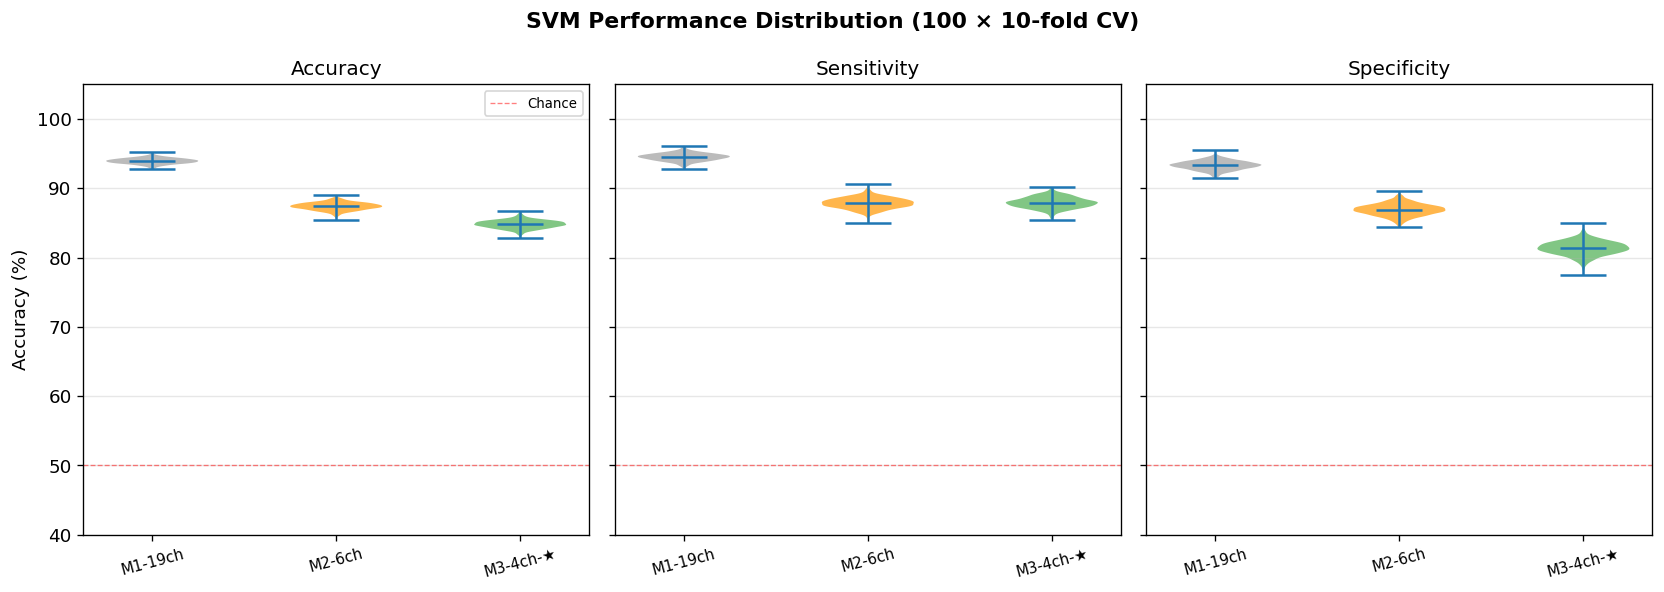

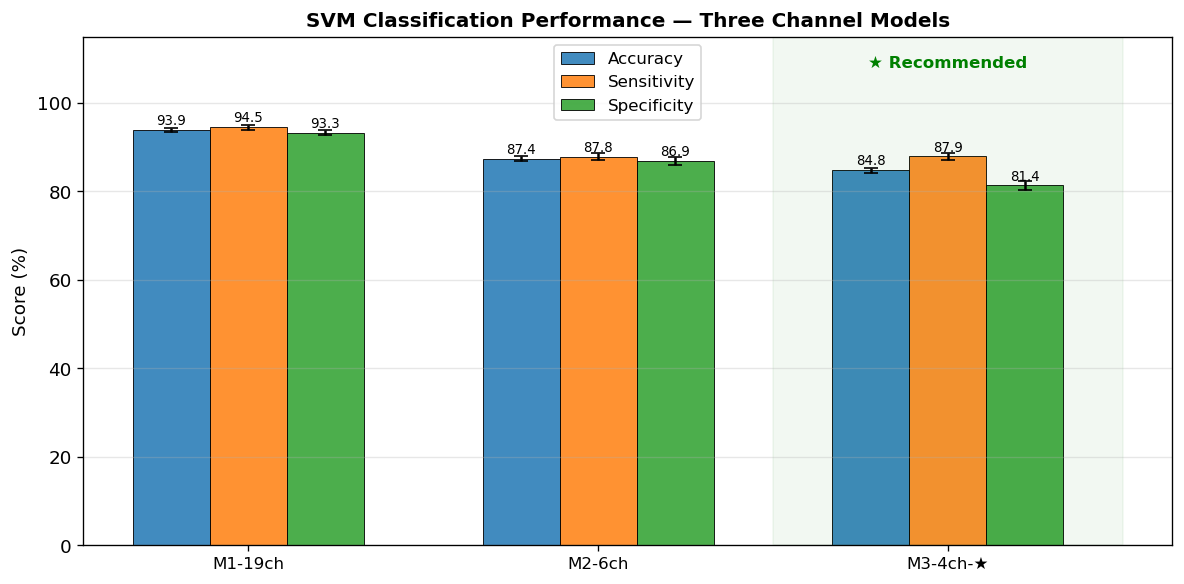

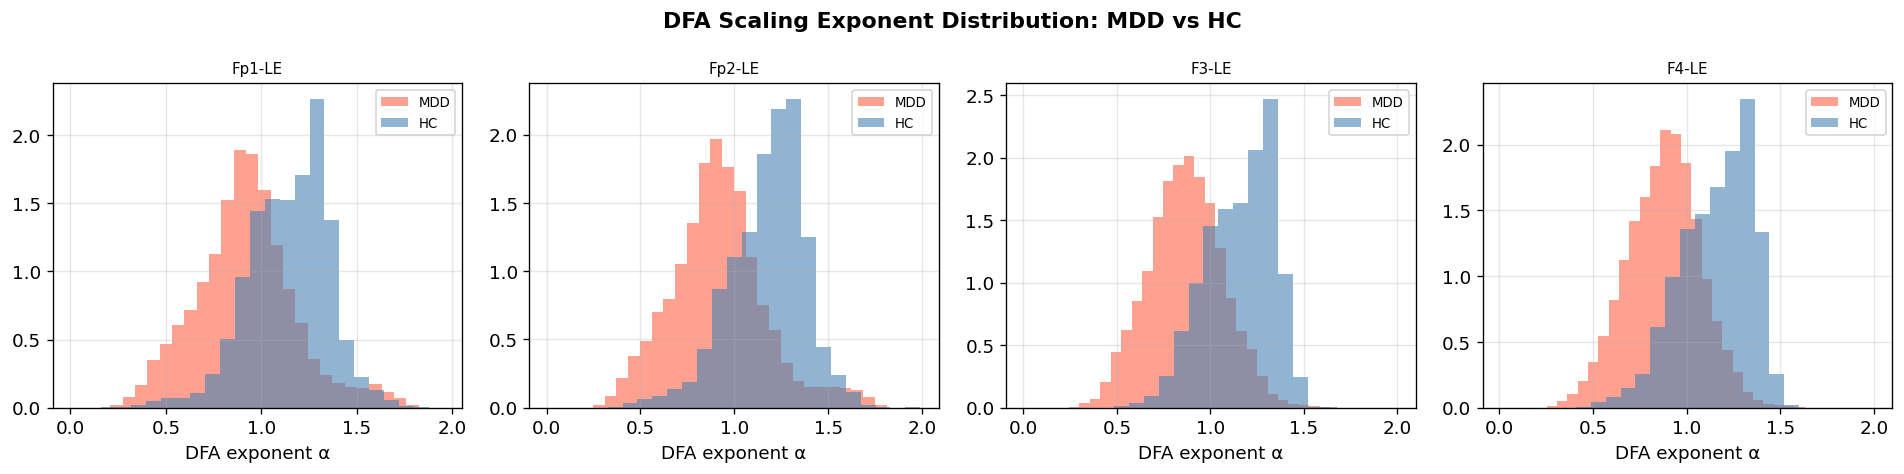

All figures saved to results/


In [18]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 12 — Figures (IEEE Paper Quality)
# ═══════════════════════════════════════════════════════════════════════════

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'figure.dpi': 120})
COLORS = {'Model1_AllCh': '#2196F3', 'Model2_6ch': '#FF9800', 'Model3_4ch_★': '#4CAF50'}

# ── Figure 1: Accuracy distribution across 100×10 folds (violin plot) ──────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
metric_plot = [('acc', 'Accuracy'), ('sen', 'Sensitivity'), ('spe', 'Specificity')]

for ax, (m_key, m_label) in zip(axes, metric_plot):
    data_plot  = [res[m_key] * 100 for res in all_results.values()]
    labels_    = list(all_results.keys())
    colors_    = [COLORS.get(n, '#9E9E9E') for n in labels_]

    vp = ax.violinplot(data_plot, positions=range(len(labels_)),
                        showmedians=True, showextrema=True)
    for body, col in zip(vp['bodies'], colors_):
        body.set_facecolor(col); body.set_alpha(0.7)

    ax.set_xticks(range(len(labels_)))
    ax.set_xticklabels([n.replace('Model','M').replace('_','-') for n in labels_],
                        fontsize=9, rotation=15)
    ax.set_ylabel(f'{m_label} (%)' if m_key == 'acc' else '')
    ax.set_title(m_label)
    ax.set_ylim(40, 105)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(50, color='red', linestyle='--', lw=0.8, alpha=0.5, label='Chance')

axes[0].legend(fontsize=8)
plt.suptitle('SVM Performance Distribution (100 × 10-fold CV)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CFG['results_dir'], 'fig_violin_metrics.png'), dpi=150)
plt.show()

# ── Figure 2: Bar chart comparison ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(3)
width   = 0.22
m_keys  = ['acc', 'sen', 'spe']
m_labs  = ['Accuracy', 'Sensitivity', 'Specificity']
models  = list(all_results.keys())

for i, (mk, ml) in enumerate(zip(m_keys, m_labs)):
    means  = [np.mean(all_results[m][mk]) * 100 for m in models]
    stds   = [np.std( all_results[m][mk]) * 100 for m in models]
    offset = (i - 1) * width
    bars   = ax.bar(x + offset, means, width, yerr=stds, capsize=4,
                     label=ml, alpha=0.85, edgecolor='black', linewidth=0.6)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{mean:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([m.replace('Model','M').replace('_','-') for m in models], fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.set_title('SVM Classification Performance — Three Channel Models', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
# Mark the recommended model
ax.axvspan(1.5, 2.5, color='green', alpha=0.05)
ax.text(2, 108, '★ Recommended', ha='center', fontsize=10, color='green', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CFG['results_dir'], 'fig_bar_comparison.png'), dpi=150)
plt.show()

# ── Figure 3: DFA exponent distribution MDD vs HC (for best model) ─────────
best_model = 'Model3_4ch_★'
if best_model in feature_store:
    F_best, fn_best = feature_store[best_model]
    dfa_indices = [i for i, n in enumerate(fn_best) if n.startswith('DFA')]

    if dfa_indices:
        fig, axes = plt.subplots(1, min(4, len(dfa_indices)),
                                  figsize=(4*min(4, len(dfa_indices)), 4))
        if len(dfa_indices) == 1:
            axes = [axes]
        for ax, di in zip(axes, dfa_indices[:4]):
            mdd_vals = F_best[y_all == 1, di]
            hc_vals  = F_best[y_all == 0, di]
            ax.hist(mdd_vals, bins=25, alpha=0.6, color='tomato',    label='MDD', density=True)
            ax.hist(hc_vals,  bins=25, alpha=0.6, color='steelblue', label='HC',  density=True)
            ax.set_title(fn_best[di].replace('DFA_','').replace('EEG_',''), fontsize=9)
            ax.set_xlabel('DFA exponent α')
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
        plt.suptitle('DFA Scaling Exponent Distribution: MDD vs HC', fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(CFG['results_dir'], 'fig_dfa_distribution.png'), dpi=150)
        plt.show()

print('All figures saved to results/')


Computing permutation importance for Model3_4ch_★...


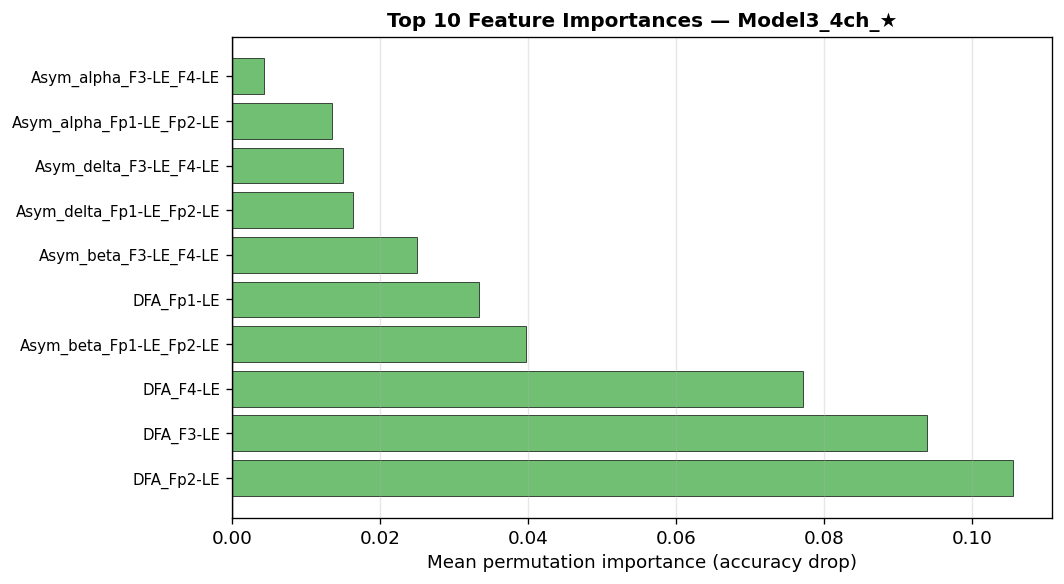


Top 10 most discriminative features:
   1. DFA_EEG_Fp2-LE                                          0.10562
   2. DFA_EEG_F3-LE                                           0.09397
   3. DFA_EEG_F4-LE                                           0.07718
   4. Asym_beta_EEG_Fp1-LE_EEG_Fp2-LE                         0.03977
   5. DFA_EEG_Fp1-LE                                          0.03339
   6. Asym_beta_EEG_F3-LE_EEG_F4-LE                           0.02501
   7. Asym_delta_EEG_Fp1-LE_EEG_Fp2-LE                        0.01636
   8. Asym_delta_EEG_F3-LE_EEG_F4-LE                          0.01501
   9. Asym_alpha_EEG_Fp1-LE_EEG_Fp2-LE                        0.01354
  10. Asym_alpha_EEG_F3-LE_EEG_F4-LE                          0.00431


In [19]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 13 — Feature Analysis
#  For RBF SVM: use permutation importance on held-out test set
#  (direct weight extraction not available for nonlinear kernels)
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.inspection import permutation_importance

def compute_permutation_importance(F, y, cfg, tag, n_repeats=5):
    """
    Train one SVM on 70% of data, compute permutation importance on 30%.
    Returns sorted feature importance array.
    """
    scaler   = MinMaxScaler()
    F_n      = scaler.fit_transform(F)

    rng      = np.random.RandomState(SEED)
    mdd_idx  = np.where(y == 1)[0]
    hc_idx   = np.where(y == 0)[0]
    n_train  = int(cfg['train_ratio'] * len(y))
    n_mdd    = int(n_train * np.mean(y == 1))
    n_hc     = n_train - n_mdd

    tr_idx   = np.concatenate([
        rng.choice(mdd_idx, min(n_mdd, len(mdd_idx)), replace=False),
        rng.choice(hc_idx,  min(n_hc,  len(hc_idx)),  replace=False)
    ])
    te_idx   = np.setdiff1d(np.arange(len(y)), tr_idx)

    svm = SVC(kernel='rbf', C=cfg['svm_C'], gamma=cfg['svm_gamma'],
              class_weight='balanced', random_state=SEED)
    svm.fit(F_n[tr_idx], y[tr_idx])

    result = permutation_importance(
        svm, F_n[te_idx], y[te_idx],
        n_repeats=n_repeats, random_state=SEED, scoring='accuracy'
    )
    return result.importances_mean


# Run on 4-channel model
best_model = 'Model3_4ch_★'
if best_model in feature_store:
    F_best, fn_best = feature_store[best_model]
    print(f'Computing permutation importance for {best_model}...')
    importance = compute_permutation_importance(F_best, y_all, CFG, best_model)

    # Sort by importance
    sort_idx = np.argsort(importance)[::-1]
    top_n    = min(15, len(fn_best))

    fig, ax = plt.subplots(figsize=(9, 5))
    y_pos   = np.arange(top_n)
    ax.barh(y_pos, importance[sort_idx[:top_n]],
            color=['#4CAF50' if importance[i] > 0 else '#F44336'
                   for i in sort_idx[:top_n]],
            alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([fn_best[i].replace('EEG_','').replace('_LE','')
                         for i in sort_idx[:top_n]], fontsize=9)
    ax.set_xlabel('Mean permutation importance (accuracy drop)')
    ax.set_title(f'Top {top_n} Feature Importances — {best_model}', fontweight='bold')
    ax.axvline(0, color='black', lw=0.8)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG['results_dir'], 'fig_feature_importance.png'), dpi=150)
    plt.show()

    # Print top features
    print('\nTop 10 most discriminative features:')
    for rank, i in enumerate(sort_idx[:10]):
        print(f'  {rank+1:2d}. {fn_best[i]:<55} {importance[i]:.5f}')


In [20]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 14 — Statistical Testing
#  Wilcoxon signed-rank test: pairwise model comparison across CV folds
# ═══════════════════════════════════════════════════════════════════════════

from scipy.stats import wilcoxon

model_names = list(all_results.keys())
print('Pairwise Wilcoxon test on accuracy distributions across 100×10 folds:')
print('─' * 65)

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        a_vals = all_results[model_names[i]]['acc']
        b_vals = all_results[model_names[j]]['acc']

        # Ensure same length
        min_len = min(len(a_vals), len(b_vals))
        try:
            stat, pval = wilcoxon(a_vals[:min_len], b_vals[:min_len])
            sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else
                  ('*'   if pval < 0.05 else 'ns'))
        except ValueError:
            pval, sig = np.nan, 'n/a'

        a_mean = np.mean(a_vals) * 100
        b_mean = np.mean(b_vals) * 100
        print(f'  {model_names[i]:<20} vs {model_names[j]:<20}  '
              f'Δ={a_mean-b_mean:+.2f}%  p={pval:.4f}  {sig}')

print('\n  *** p<0.001  ** p<0.01  * p<0.05  ns=not significant')
print('\nNote: With 1000 folds the test is highly powered; even tiny differences')
print('      may be statistically significant but clinically irrelevant.')
print('      Report effect size (Δ%) alongside p-values in the paper.')


Pairwise Wilcoxon test on accuracy distributions across 100×10 folds:
─────────────────────────────────────────────────────────────────
  Model1_19ch          vs Model2_6ch            Δ=+6.54%  p=0.0000  ***
  Model1_19ch          vs Model3_4ch_★          Δ=+9.14%  p=0.0000  ***
  Model2_6ch           vs Model3_4ch_★          Δ=+2.60%  p=0.0000  ***

  *** p<0.001  ** p<0.01  * p<0.05  ns=not significant

Note: With 1000 folds the test is highly powered; even tiny differences
      may be statistically significant but clinically irrelevant.
      Report effect size (Δ%) alongside p-values in the paper.


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 15 — Final Summary & Supervisor Checklist
# ═══════════════════════════════════════════════════════════════════════════

print('╔' + '═'*65 + '╗')
print('║  FINAL PIPELINE SUMMARY                                         ║')
print('╠' + '═'*65 + '╣')
print(f'║  Total epochs (merged)  : {len(X_all):<35} ║')
print(f'║  MDD epochs             : {int(np.sum(y_all==1)):<35} ║')
print(f'║  HC  epochs             : {int(np.sum(y_all==0)):<35} ║')
print(f'║  Features (4-ch model)  : {feature_store["Model3_4ch_★"][0].shape[1]:<35} ║')
print(f'║  SVM repeats            : {CFG["n_repeats"]} × {CFG["k_folds"]}-fold CV{" "*22}║')
print('╠' + '═'*65 + '╣')
print('║  RESULTS (Mean ± Std across all folds):                         ║')
for model_name, res in all_results.items():
    star = '★' if '4ch' in model_name else ' '
    line = f'{star} {model_name:<22} Acc={np.mean(res["acc"])*100:.2f}%  Sen={np.mean(res["sen"])*100:.2f}%  Spe={np.mean(res["spe"])*100:.2f}%'
    print(f'║  {line:<63} ║')
print('╠' + '═'*65 + '╣')
print('║  REVIEWER CHECKLIST — open items for Q1 paper:                  ║')
items = [
    '□ Confirm channel names match exactly for both datasets',
    '□ Validate ICA removed blinks (plot IC topomaps)',
    '□ Report epoch rejection rate per subject',
    '□ Add subject-wise split (current is epoch-wise)',
    '□ DFA: justify scale range [10–200 samples] in methods',
    '□ Ablation: test asymmetry-only vs DFA-only vs combined',
    '□ Plot asymmetry index MDD vs HC per band (Figure)',
    '□ Statistical test: compare models + report effect size',
    '□ External validation: test on held-out dataset',
]
for item in items:
    print(f'║  {item:<63} ║')
print('╚' + '═'*65 + '╝')


╔═════════════════════════════════════════════════════════════════╗
║  FINAL PIPELINE SUMMARY                                         ║
╠═════════════════════════════════════════════════════════════════╣
║  Total epochs (merged)  : 34060                               ║
║  MDD epochs             : 17841                               ║
║  HC  epochs             : 16219                               ║
║  Features (4-ch model)  : 10                                  ║
║  SVM repeats            : 100 × 10-fold CV                      ║
╠═════════════════════════════════════════════════════════════════╣
║  RESULTS (Mean ± Std across all folds):                         ║
║    Model1_19ch            Acc=93.93%  Sen=94.50%  Spe=93.30%     ║
║    Model2_6ch             Acc=87.39%  Sen=87.85%  Spe=86.89%     ║
║  ★ Model3_4ch_★           Acc=84.79%  Sen=87.92%  Spe=81.35%     ║
╠═════════════════════════════════════════════════════════════════╣
║  REVIEWER CHECKLIST — open items for Q1 paper:     